## Problem Statement

### Context:

To minimize the loss of human life from a medical perspective, doctors and hospitals need a reliable decision rule regarding whom to classify as a malignant cancer patient and whom to classify as benign. A patient's physical and biological cell measurements are considered by medical professionals before a diagnosis is made regarding his/her cancer condition. In this dataset, each entry represents a person whose breast tissue cells were examined. Each person is classified as Malignant or Benign according to the set of measured cell attributes.


### Objective:

The objective is to build a predictive model on this data to help medical professionals decide whether a patient's breast cancer tumor is Malignant (cancerous) or Benign (non-cancerous) based on digitized cell nucleus measurements from a breast mass.


### Dataset:

- id (Numeric: Unique identifier for each patient — dropped during preprocessing)
- diagnosis (Category: M = Malignant, B = Benign) ← Target Variable
- radius_mean (Numeric: Mean of distances from center to points on the perimeter)
- texture_mean (Numeric: Standard deviation of gray-scale values)
- perimeter_mean (Numeric: Mean size of the core tumor perimeter)
- area_mean (Numeric: Mean area of the tumor)
- smoothness_mean (Numeric: Mean of local variation in radius lengths)
- compactness_mean (Numeric: Mean of perimeter² / area − 1.0)
- concavity_mean (Numeric: Mean of severity of concave portions of the contour)
- concave points_mean (Numeric: Mean number of concave portions of the contour)
- symmetry_mean (Numeric: Mean symmetry of the cell nucleus)
- fractal_dimension_mean (Numeric: Mean coastline approximation − 1)
- (Similarly SE and Worst versions of all 10 features above — 30 features total)
- Risk / Diagnosis (0 = Person is Benign / not at risk, 1 = Person is Malignant / at risk of cancer)

## Importing Necessary Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [ ]:
df=pd.read_csv(r"C:\Users\HP\Downloads\Breast Cancer Dataset.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


* Reads the CSV file and stores it as a DataFrame (table format). df is just a short name for dataframe.

In [ ]:
print("Shape:",df.shape)

Shape: (569, 33)


* Prints how many rows and columns are in the dataset. Output will be (569, 33) — 569 patients, 33 columns.

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


* Shows the first 5 rows so you can visually see what the data looks like.

In [ ]:
print(df.dtypes)

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

* Shows the data type of each column — whether it's a number (int/float) or text (object).

In [ ]:
print(df['diagnosis'].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


* Counts how many Malignant (M) and Benign (B) cases are in the dataset. Output: B=357, M=212. This tells us the dataset is slightly imbalanced.

In [ ]:
print(df.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

* Shows statistical summary for every numeric column — min, max, mean, standard deviation, quartiles. Helps spot if any column has weird values or extreme ranges.

In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

* Prints all 33 column names in a list so you know exactly what features are available.

### Data Cleaning

In [ ]:
df.drop(columns=['id'], inplace=True)

* Removes the id column completely. It's just a patient ID number — it has no medical meaning and would confuse the model if kept. inplace=True means change the original dataframe directly.

In [ ]:
df.drop(columns=['Unnamed: 32'], inplace=True)

* Removes Unnamed: 32 — this column is completely empty (all 569 values are NaN). It was created because the CSV has an extra comma at the end of each row.

In [ ]:
print(df.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


* Counts how many missing (NaN) values exist in each column. After dropping those two columns, every column should show 0 — meaning no missing data.

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


* Checks if any two rows are exactly identical. If duplicates exist, they would train the model on the same data twice and cause overfitting. Here the result is 0 — no duplicates.

In [ ]:
features = df.drop(columns=['diagnosis']).columns
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers")

radius_mean: 14 outliers
texture_mean: 7 outliers
perimeter_mean: 13 outliers
area_mean: 25 outliers
smoothness_mean: 6 outliers
compactness_mean: 16 outliers
concavity_mean: 18 outliers
concave points_mean: 10 outliers
symmetry_mean: 15 outliers
fractal_dimension_mean: 15 outliers
radius_se: 38 outliers
texture_se: 20 outliers
perimeter_se: 38 outliers
area_se: 65 outliers
smoothness_se: 30 outliers
compactness_se: 28 outliers
concavity_se: 22 outliers
concave points_se: 19 outliers
symmetry_se: 27 outliers
fractal_dimension_se: 28 outliers
radius_worst: 17 outliers
texture_worst: 5 outliers
perimeter_worst: 15 outliers
area_worst: 35 outliers
smoothness_worst: 7 outliers
compactness_worst: 16 outliers
concavity_worst: 12 outliers
symmetry_worst: 23 outliers
fractal_dimension_worst: 24 outliers


* For each feature column, this calculates the IQR (Interquartile Range). Any value that falls below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is considered an outlier. We are just counting them and printing — not removing — because in medical data, extreme values can be genuinely important diagnostic signals.

## <a name='link2'>Exploratory Data Analysis (EDA) Summary</a>

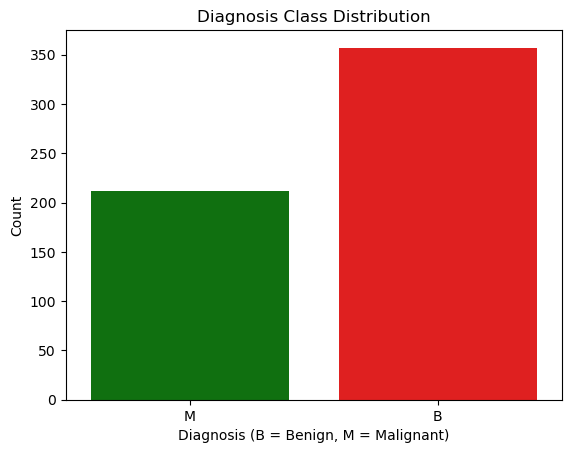

In [ ]:
sns.countplot(x="diagnosis", data=df,palette=["green", "red"], hue="diagnosis")
plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis (B = Benign, M = Malignant)")
plt.ylabel("Count")
plt.show()

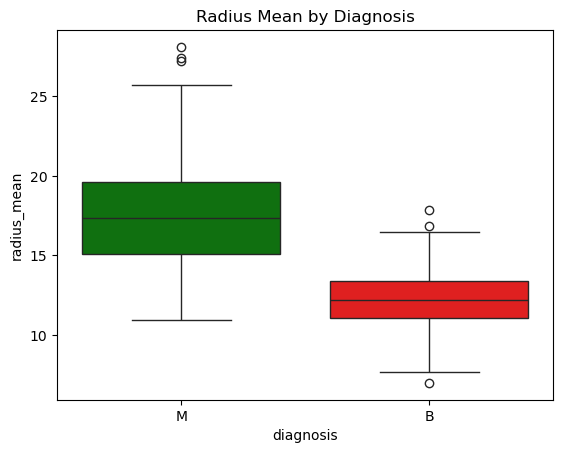

In [ ]:
sns.boxplot(x="diagnosis", y="radius_mean",data=df, palette=["green", "red"])
plt.title("Radius Mean by Diagnosis")
plt.show()

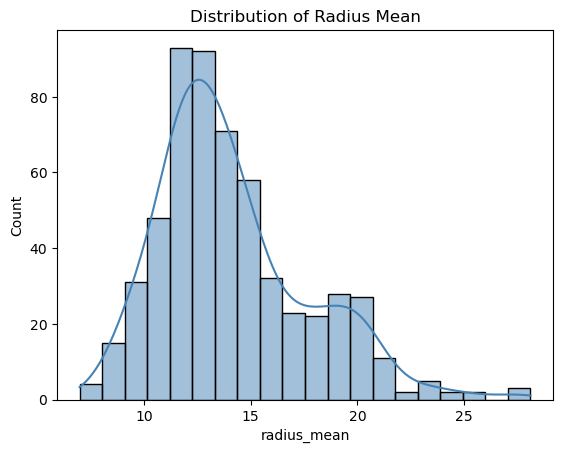

In [ ]:
sns.histplot(df["radius_mean"], kde=True,color="steelblue", bins=20)
plt.title("Distribution of Radius Mean")
plt.show()

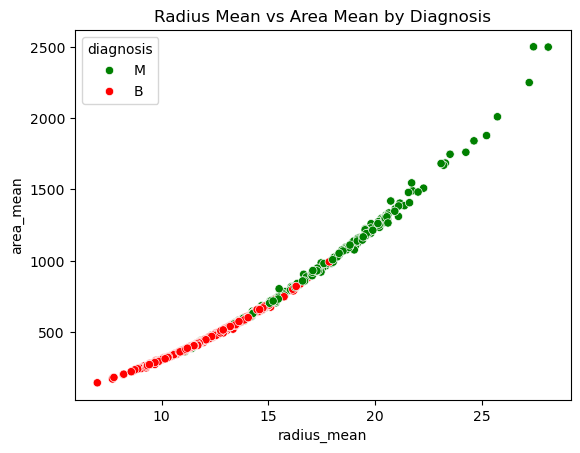

In [ ]:
sns.scatterplot(x="radius_mean", y="area_mean",hue="diagnosis", data=df,palette=["green", "red"])
plt.title("Radius Mean vs Area Mean by Diagnosis")
plt.show()

### Data Preprocessing

In [ ]:
le=LabelEncoder()
df['diagnosis']=le.fit_transform(df['diagnosis'])

* LabelEncoder converts the text column diagnosis into numbers. B → 0 and M → 1. Machine learning models only understand numbers, not strings. fit_transform first learns the mapping, then applies it.

In [ ]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

* Splits the data into two parts. X contains all 30 feature columns (the inputs — cell measurements). y contains only the target column (the output — 0 or 1). This is the standard ML convention.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

* Splits data into 80% training and 20% testing. random_state=42 makes the split reproducible — same split every time you run it. stratify=y ensures both train and test sets have the same M/B ratio as the original dataset (proportional split).

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

* KNN works by calculating distance between points. If one feature has values 0–2500 (like area) and another has values 0–0.2 (like smoothness), the large-valued feature will completely dominate the distance calculation. StandardScaler fixes this by converting every feature to mean=0 and std=1. Important: fit_transform is used only on train data. On test data only transform is used — because in real life you don't know test data in advance, so you must not let it influence the scaling.

Best K: 11


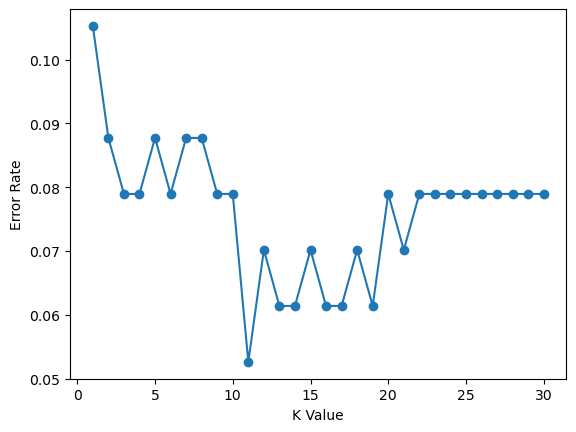

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

error_rates = []

for i in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)

    pred_i = knn.predict(X_test)

    error_rates.append(np.mean(pred_i != y_test))

best_k = error_rates.index(min(error_rates)) + 1

print("Best K:", best_k)

plt.plot(range(1, 31), error_rates, marker='o')
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.show()

### Find Best k

In [ ]:
best_k = error_rates.index(min(error_rates)) + 1

* Finds the K value where error was minimum. +1 because list index starts at 0 but K starts at 1.

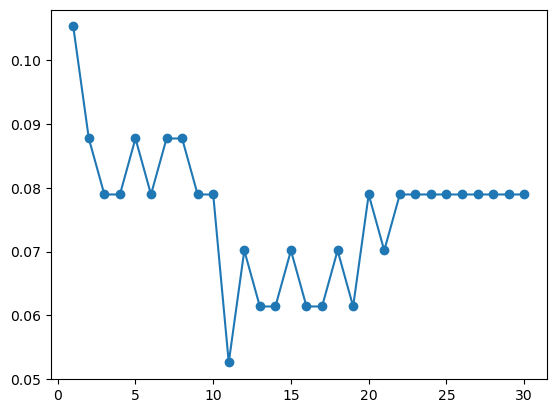

In [ ]:
plt.plot(range(1, 31), error_rates, marker='o')
plt.show()

* Plots the elbow curve — a graph of K vs error rate. You look for the "elbow" point where error stops decreasing significantly. That is your best K.

### Train KNN Model

In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='uniform')
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=11)

* Creates the final KNN model with the best K found above. metric='euclidean' means straight-line distance between points in 30D space. weights='uniform' means all K neighbours get equal voting power. .fit() trains the model on the training data — KNN simply memorizes all training points.

## Evaluate Model

In [ ]:
y_pred = knn.predict(X_test_scaled)

* Model looks at each test sample, finds its K nearest neighbours from training data, takes a majority vote, and returns prediction (0 or 1).

In [ ]:
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

* Instead of just 0 or 1, this gives a probability score between 0 and 1. [:, 1] selects the probability of being Malignant (class 1). Used later for ROC curve.

In [ ]:
accuracy_score(y_test, y_pred)

0.9473684210526315

* Percentage of total predictions that were correct. Formula: (TP + TN) / Total

In [ ]:
precision_score(y_test, y_pred)

0.9736842105263158

* Out of all cases predicted as Malignant, how many actually were Malignant. Formula: TP / (TP + FP). High precision = fewer false alarms.

In [ ]:
recall_score(y_test, y_pred)

0.8809523809523809

* Out of all actual Malignant cases, how many did the model correctly catch. Formula: TP / (TP + FN). High recall = fewer missed cancers. In medical diagnosis, recall is more critical than precision.

In [ ]:
f1_score(y_test, y_pred)

0.925

* Harmonic mean of precision and recall. Gives a single balanced score when both matter. Formula: 2 * (Precision * Recall) / (Precision + Recall)

In [ ]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.93      0.99      0.96        72\n           1       0.97      0.88      0.93        42\n\n    accuracy                           0.95       114\n   macro avg       0.95      0.93      0.94       114\nweighted avg       0.95      0.95      0.95       114\n'

* Prints a full table showing precision, recall, F1, and support (sample count) for both classes — Benign and Malignant — together.

### Confusion Matrix

<Axes: >

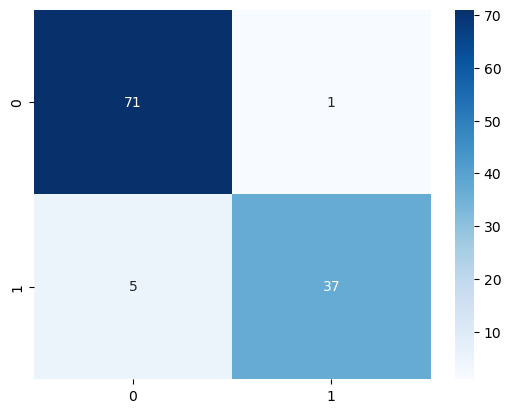

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

* Creates a 2x2 matrix showing 4 types of results. annot=True prints the numbers inside each box. fmt='d' means display as integer.

In [ ]:
tn, fp, fn, tp = cm.ravel()

* Unpacks the 4 values from confusion matrix. TP = correctly predicted Malignant. TN = correctly predicted Benign. FP = Benign predicted as Malignant (false alarm). FN = Malignant predicted as Benign (most dangerous mistake in cancer detection).

### ROC Curve

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

* ROC curve plots True Positive Rate vs False Positive Rate at different decision thresholds. AUC (Area Under Curve) summarizes the whole curve in one number. AUC = 1.0 is perfect, AUC = 0.5 is random guessing. Our model should get ~0.97–0.99.

In [ ]:
plt.plot([0, 1], [0, 1], linestyle='--')
plt.show()

* This dashed diagonal line represents a random classifier (AUC = 0.5). Our model's curve should be far above this line — the further above, the better.

In [ ]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric'     : ['euclidean', 'manhattan', 'minkowski'],
    'weights'    : ['uniform', 'distance']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

* Instead of manually trying every combination of K, distance metric, and weights — GridSearchCV does it automatically. It tries all combinations (20 × 3 × 2 = 120 combinations), evaluates each with 5-fold CV, and picks the best one. n_jobs=-1 uses all CPU cores to run faster.

In [ ]:
print("Best Params:", grid.best_params_)

Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


* Prints the winning combination — e.g. {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}.

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

* PCA (Principal Component Analysis) compresses 30 features down to just 2 — the 2 directions that capture the most variation in the data. This is done purely for visualization because we can't plot in 30 dimensions.